In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
# Load CIFAR-10 dataset

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1895s 11us/step
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 1)


In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
num_classes = 10

y_train_cat = to_categorical(y_train, num_classes)

y_test_cat = to_categorical(y_test, num_classes)

In [ ]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

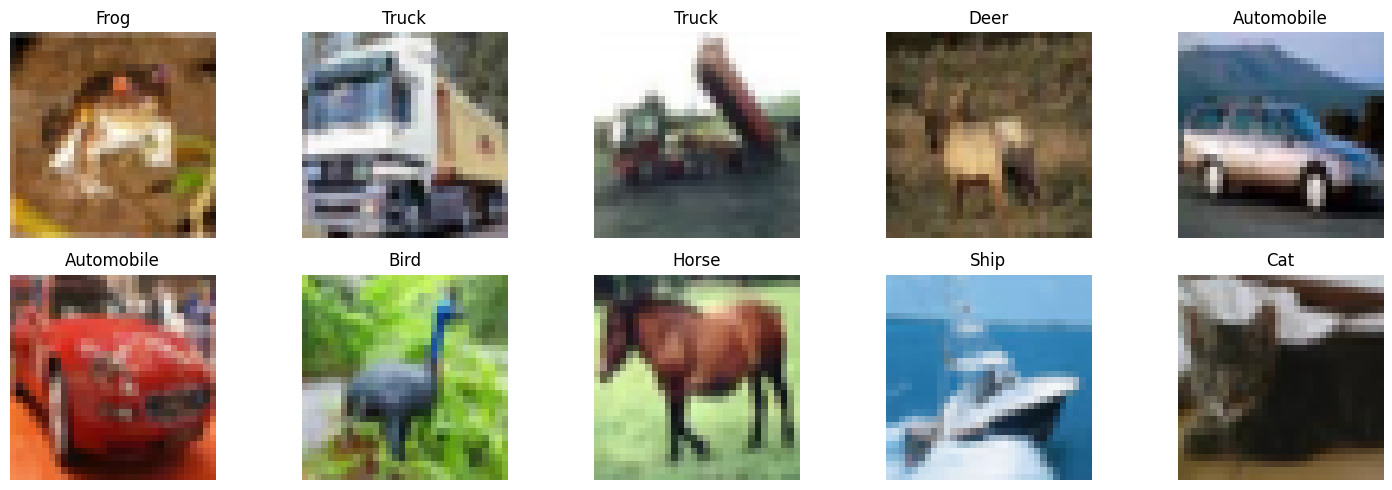

In [ ]:
plt.figure(figsize=(15,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis("off")

plt.tight_layout()

plt.show()

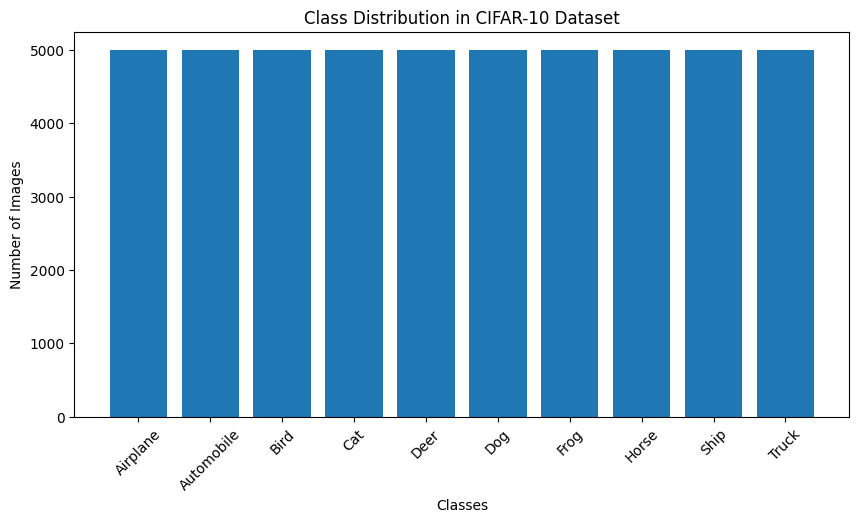

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.xticks(rotation=45)

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.title("Class Distribution in CIFAR-10 Dataset")

plt.show()

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D

def convolution_model(kernel_size):

    model = Sequential([
        Conv2D(
            filters=8,
            kernel_size=(kernel_size, kernel_size),
            strides=(1,1),
            padding='valid',
            activation='relu',
            input_shape=(32,32,3)
        )
    ])

    return model

In [ ]:
model3 = convolution_model(3)
model5 = convolution_model(5)
model7 = convolution_model(7)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
sample = X_train[0]
sample = np.expand_dims(sample, axis=0)

In [ ]:
feature3 = model3.predict(sample)

feature5 = model5.predict(sample)

feature7 = model7.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


In [ ]:
print("Input Image Shape :", sample.shape)

print("\n3 × 3 Kernel Feature Map :", feature3.shape)

print("5 × 5 Kernel Feature Map :", feature5.shape)

print("7 × 7 Kernel Feature Map :", feature7.shape)

Input Image Shape : (1, 32, 32, 3)

3 × 3 Kernel Feature Map : (1, 30, 30, 8)
5 × 5 Kernel Feature Map : (1, 28, 28, 8)
7 × 7 Kernel Feature Map : (1, 26, 26, 8)


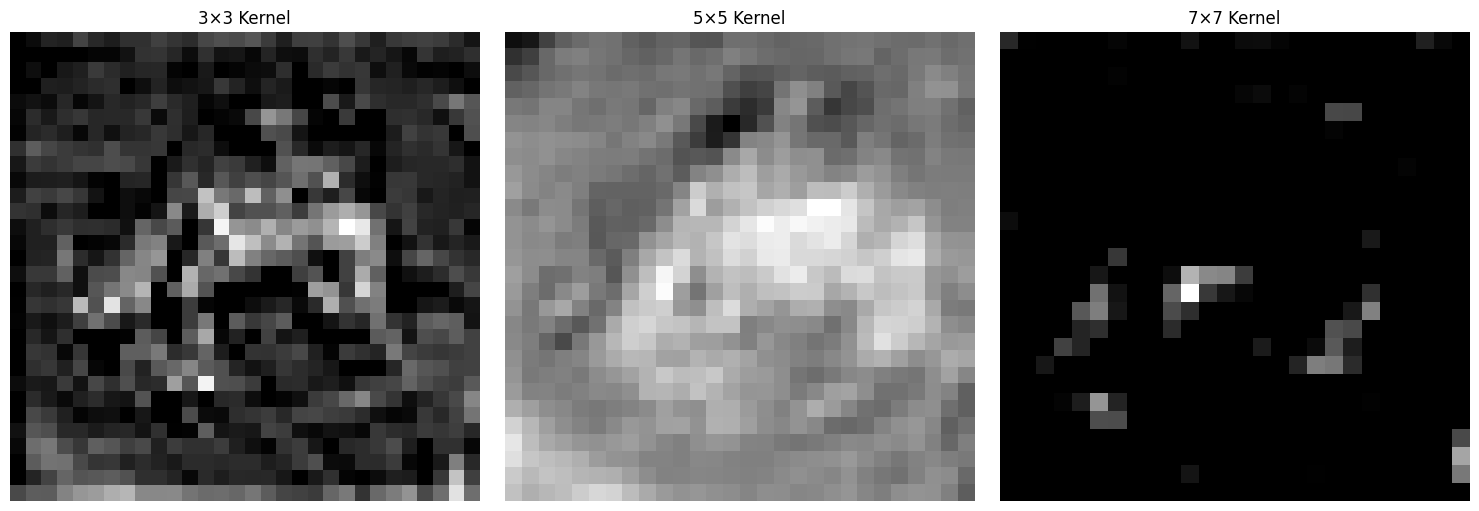

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(feature3[0,:,:,0], cmap='gray')
plt.title("3×3 Kernel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(feature5[0,:,:,0], cmap='gray')
plt.title("5×5 Kernel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(feature7[0,:,:,0], cmap='gray')
plt.title("7×7 Kernel")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

def build_conv_model(kernel_size=3, stride=1, padding='valid'):

    model = Sequential([
        Conv2D(
            filters=8,
            kernel_size=(kernel_size, kernel_size),
            strides=(stride, stride),
            padding=padding,
            activation='relu',
            input_shape=(32,32,3)
        )
    ])

    return model

In [ ]:
model_stride1 = build_conv_model(stride=1, padding='valid')

model_stride2 = build_conv_model(stride=2, padding='valid')

model_same = build_conv_model(stride=1, padding='same')

model_valid = build_conv_model(stride=1, padding='valid')

In [ ]:
feature_stride1 = model_stride1.predict(sample)

feature_stride2 = model_stride2.predict(sample)

feature_same = model_same.predict(sample)

feature_valid = model_valid.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


In [ ]:
print("Input Shape :", sample.shape)

print("\nStride = 1")
print(feature_stride1.shape)

print("\nStride = 2")
print(feature_stride2.shape)

print("\nPadding = SAME")
print(feature_same.shape)

print("\nPadding = VALID")
print(feature_valid.shape)

Input Shape : (1, 32, 32, 3)

Stride = 1
(1, 30, 30, 8)

Stride = 2
(1, 15, 15, 8)

Padding = SAME
(1, 32, 32, 8)

Padding = VALID
(1, 30, 30, 8)


In [ ]:
import math

def output_size(N, F, S, P):
    return math.floor((N - F + 2*P)/S) + 1

In [ ]:
print(output_size(32,3,1,0))

30


In [ ]:
print(output_size(32,3,2,0))

15


In [ ]:
print("Output Size =",32)

Output Size = 32


In [ ]:
print("-"*55)
print("{:<20}{:<20}".format("Hyperparameter","Output Size"))
print("-"*55)

print("{:<20}{:<20}".format("Stride = 1","30 x 30"))
print("{:<20}{:<20}".format("Stride = 2","15 x 15"))
print("{:<20}{:<20}".format("Padding = SAME","32 x 32"))
print("{:<20}{:<20}".format("Padding = VALID","30 x 30"))

-------------------------------------------------------
Hyperparameter      Output Size         
-------------------------------------------------------
Stride = 1          30 x 30             
Stride = 2          15 x 15             
Padding = SAME      32 x 32             
Padding = VALID     30 x 30             


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model

inputs = Input(shape=(32, 32, 3))

conv = Conv2D(
    filters=8,
    kernel_size=(3, 3),
    activation='relu',
    name='First_Conv'
)(inputs)

pool = MaxPooling2D(pool_size=(2, 2))(conv)

cnn = Model(inputs=inputs, outputs=pool)

cnn.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ First_Conv (Conv2D)             │ (None, 30, 30, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 8)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224 (896.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
feature_model = Model(
    inputs=cnn.input,
    outputs=cnn.get_layer("First_Conv").output
)

In [ ]:
sample = np.expand_dims(X_train[0], axis=0)

feature_maps = feature_model.predict(sample)

print("Feature Map Shape:", feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Feature Map Shape: (1, 30, 30, 8)


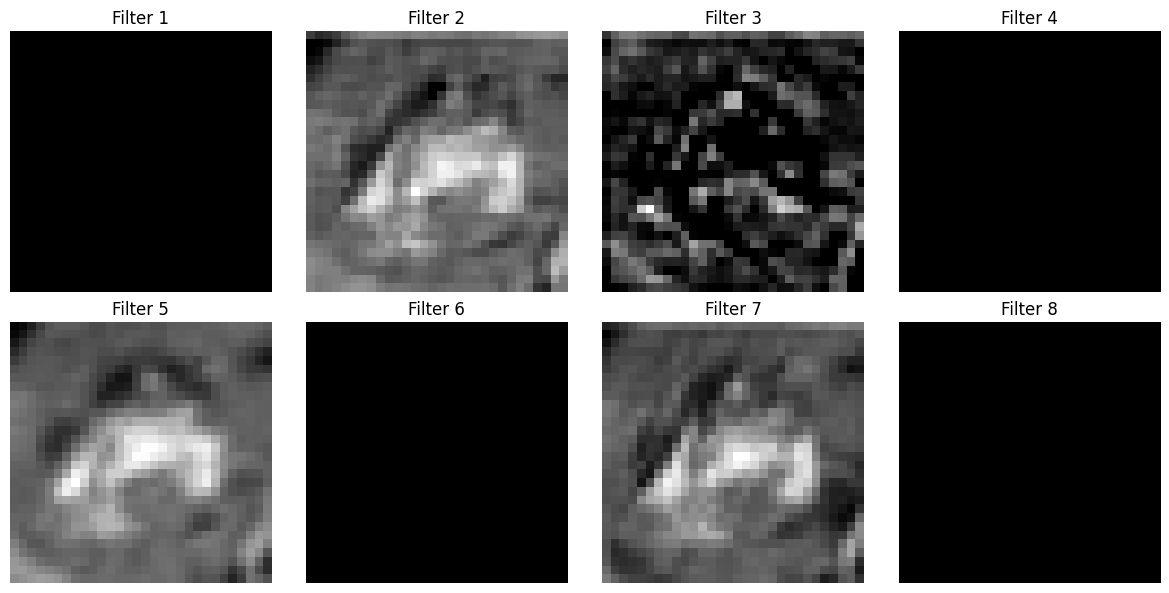

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='gray')
    plt.title(f"Filter {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    Flatten,
    Dense
)
from tensorflow.keras.models import Model

def create_cnn(pooling="max"):

    inputs = Input(shape=(32,32,3))

    x = Conv2D(16, (3,3), activation='relu')(inputs)

    if pooling == "max":
        x = MaxPooling2D((2,2))(x)
    else:
        x = AveragePooling2D((2,2))(x)

    x = Conv2D(32, (3,3), activation='relu')(x)

    if pooling == "max":
        x = MaxPooling2D((2,2))(x)
    else:
        x = AveragePooling2D((2,2))(x)

    x = Flatten()(x)

    x = Dense(64, activation='relu')(x)

    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
max_model = create_cnn("max")

avg_model = create_cnn("avg")

In [ ]:
max_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,530 (310.66 KB)

 Trainable params: 79,530 (310.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_max = max_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.4386 - loss: 1.5512 - val_accuracy: 0.5328 - val_loss: 1.3014
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.5713 - loss: 1.2160 - val_accuracy: 0.5785 - val_loss: 1.2155
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6204 - loss: 1.0859 - val_accuracy: 0.6297 - val_loss: 1.0765
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6469 - loss: 1.0115 - val_accuracy: 0.6443 - val_loss: 1.0341
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6678 - loss: 0.9524 - val_accuracy: 0.6474 - val_loss: 1.0322
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6836 - loss: 0.9037 - val_accuracy: 0.6531 - val_loss: 1.0127
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6992 - loss: 0.8680 - val_accuracy: 0.6471 - val_loss: 1.0243
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7113 - loss: 0.8255 

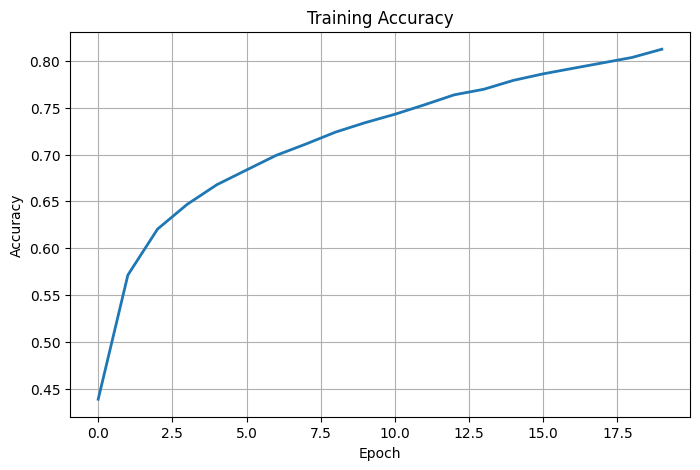

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_max.history['accuracy'], linewidth=2)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

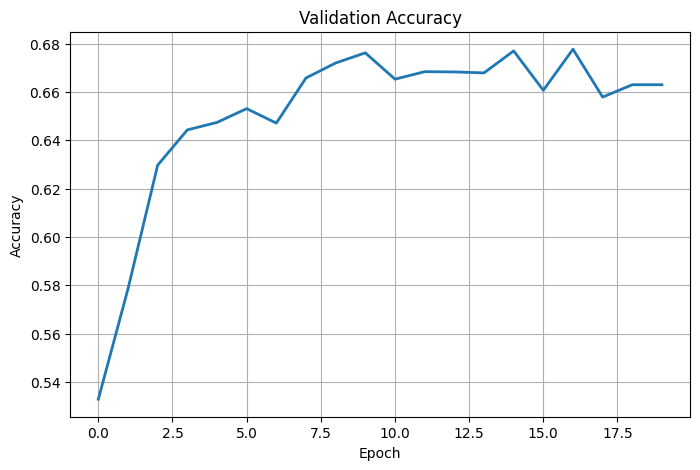

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_max.history['val_accuracy'], linewidth=2)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

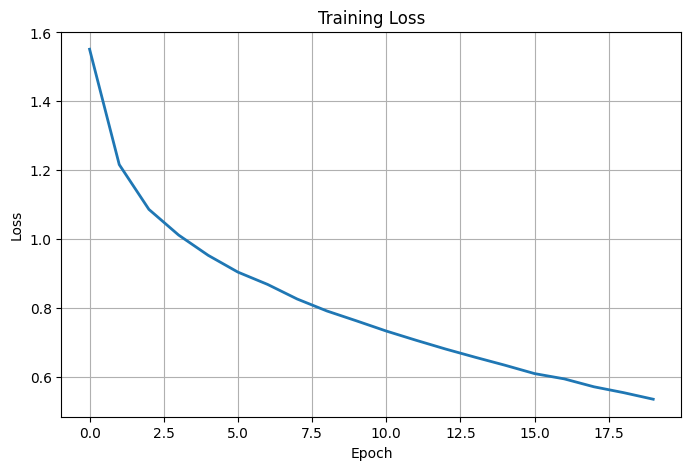

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_max.history['loss'], linewidth=2)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

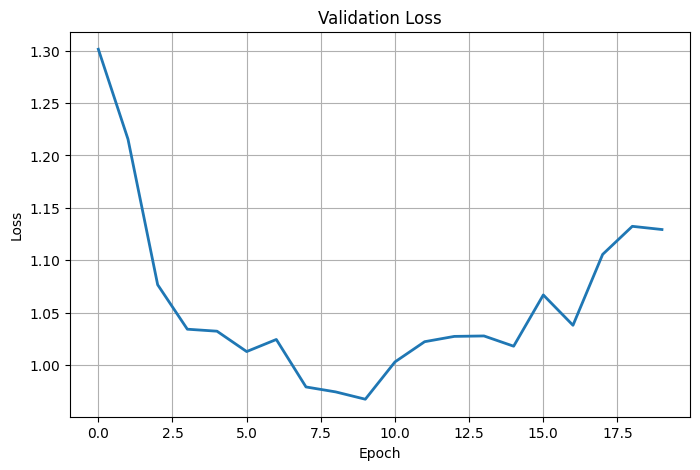

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_max.history['val_loss'], linewidth=2)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [ ]:
y_pred_prob = max_model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='weighted')

recall = recall_score(y_true, y_pred, average='weighted')

f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Accuracy : 0.663
Precision : 0.6708394203758621
Recall : 0.663
F1 Score : 0.6640803175891897


<Figure size 1000x800 with 0 Axes>

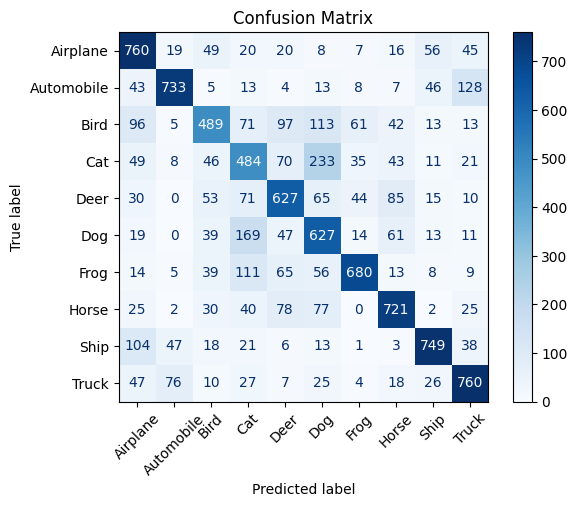

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.64      0.76      0.70      1000
  Automobile       0.82      0.73      0.77      1000
        Bird       0.63      0.49      0.55      1000
         Cat       0.47      0.48      0.48      1000
        Deer       0.61      0.63      0.62      1000
         Dog       0.51      0.63      0.56      1000
        Frog       0.80      0.68      0.73      1000
       Horse       0.71      0.72      0.72      1000
        Ship       0.80      0.75      0.77      1000
       Truck       0.72      0.76      0.74      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



In [ ]:
print("Total Trainable Parameters :", max_model.count_params())

Total Trainable Parameters : 79530


In [ ]:
history_avg = avg_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.4338 - loss: 1.5621 - val_accuracy: 0.5035 - val_loss: 1.3834
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5425 - loss: 1.2845 - val_accuracy: 0.5635 - val_loss: 1.2224
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5890 - loss: 1.1622 - val_accuracy: 0.5993 - val_loss: 1.1305
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6186 - loss: 1.0822 - val_accuracy: 0.6212 - val_loss: 1.0757
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6438 - loss: 1.0215 - val_accuracy: 0.6282 - val_loss: 1.0609
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6611 - loss: 0.9735 - val_accuracy: 0.6394 - val_loss: 1.0340
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6742 - loss: 0.9319 - val_accuracy: 0.6549 - val_loss: 0.9972
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6891 - loss: 0.8915 

In [ ]:
y_pred_prob_avg = avg_model.predict(X_test)

y_pred_avg = np.argmax(y_pred_prob_avg, axis=1)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
accuracy_avg = accuracy_score(y_true, y_pred_avg)

precision_avg = precision_score(
    y_true,
    y_pred_avg,
    average='weighted'
)

recall_avg = recall_score(
    y_true,
    y_pred_avg,
    average='weighted'
)

f1_avg = f1_score(
    y_true,
    y_pred_avg,
    average='weighted'
)

print("Accuracy :", accuracy_avg)
print("Precision :", precision_avg)
print("Recall :", recall_avg)
print("F1 Score :", f1_avg)

Accuracy : 0.6725
Precision : 0.6722361568155415
Recall : 0.6725
F1 Score : 0.6701860120227214


In [ ]:
print("="*70)
print("{:<20}{:<15}{:<15}".format("Metric","Max Pool","Average Pool"))
print("="*70)

print("{:<20}{:<15.4f}{:<15.4f}".format(
    "Accuracy",
    accuracy,
    accuracy_avg
))

print("{:<20}{:<15.4f}{:<15.4f}".format(
    "Precision",
    precision,
    precision_avg
))

print("{:<20}{:<15.4f}{:<15.4f}".format(
    "Recall",
    recall,
    recall_avg
))

print("{:<20}{:<15.4f}{:<15.4f}".format(
    "F1 Score",
    f1,
    f1_avg
))

Metric              Max Pool       Average Pool   
Accuracy            0.6630         0.6725         
Precision           0.6708         0.6722         
Recall              0.6630         0.6725         
F1 Score            0.6641         0.6702         


In [ ]:
print("Output size after 1st Pooling : 15 × 15")

print("Output size after 2nd Pooling : 6 × 6")

Output size after 1st Pooling : 15 × 15
Output size after 2nd Pooling : 6 × 6
